In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
from src.data.grid import MagnetGridIterator
iterator = MagnetGridIterator(
    "../data/processed/batch_6/grid_voxel_size_4_data_type_float32",
    phase_samples_per_simulation=2,
)

In [6]:
import pytorch_lightning as pl
from src.models import UNet3D
from src.utils import StandardNormalizer
from src.train.lit_mrifield import LitMRIField

BASE_DIR = "../data/processed/batch_6/grid_voxel_size_4_data_type_float32"
#BASE_DIR = "/anvme/workspace/b190cb11-magnet/data/processed/train/grid_voxel_size_4_data_type_float32"

model = UNet3D(in_channels=5, out_channels=12)

input_normalizer = StandardNormalizer.load_from_json(f"{BASE_DIR}/normalization/input_normalization.json")
target_normalizer = StandardNormalizer.load_from_json(f"{BASE_DIR}/normalization/target_normalization.json")

lit_model = LitMRIField(BASE_DIR, model, input_normalizer, target_normalizer)

/Users/mariusbohn/Documents/Studium/MA/ma_bohn/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/Users/mariusbohn/Documents/Studium/MA/ma_bohn/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'input_normalizer' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['input_normalizer'])`.
/Users/mariusbohn/Documents/Studium/MA/ma_bohn/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'target_normalizer' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['target_normalizer'])`.


In [9]:
import torch
from torch.utils.data import DataLoader

dl = DataLoader(iterator, batch_size=1, num_workers=4)
item = next(iter(dl))

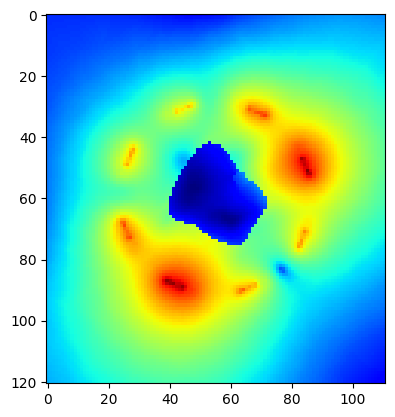

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Ground truth

re = item['field'][0, 0, 0, :, :, :, :]
im = item['field'][0, 0, 1, :, :, :, :]

result = torch.norm(torch.complex(re, im), dim=0)

plt.imshow(result[:, :, 35].cpu().numpy(), cmap='jet', norm='log')
plt.show()

In [23]:
from src.train.lit_mrifield import LitMRIField
from src.utils import StandardNormalizer
import einops

BASE_DIR = "../data/processed/batch_6/grid_voxel_size_4_data_type_float32"

trained_model = LitMRIField.load_from_checkpoint(
    'lightning_logs/version_2189746/checkpoints/epoch=9-step=1310.ckpt',
    data_path=BASE_DIR
    )
trained_model.eval()

input_normalizer = StandardNormalizer.load_from_json(f"{BASE_DIR}/normalization/input_normalization.json")
inputs = item['input']
coils = item['coils']

x = input_normalizer(torch.cat((inputs, coils), dim=1))

pred = einops.rearrange(trained_model(x), 'b (he reim xyz) ... -> b he reim xyz ...', he=2, reim=2, xyz=3)

/Users/mariusbohn/Documents/Studium/MA/ma_bohn/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/Users/mariusbohn/Documents/Studium/MA/ma_bohn/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'input_normalizer' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['input_normalizer'])`.
/Users/mariusbohn/Documents/Studium/MA/ma_bohn/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'target_normalizer' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['target_normalizer'])`.


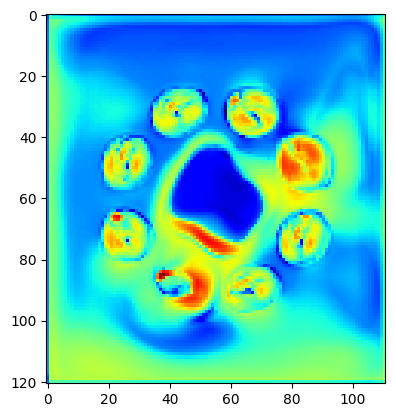

In [24]:
re = pred[0, 0, 0, :, :, :, :]
im = pred[0, 0, 1, :, :, :, :]

result = torch.norm(torch.complex(re, im), dim=0)

plt.imshow(result[:, :, 35].detach().numpy(), cmap='jet', norm='log')
plt.show()

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs/